In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.datasets import MNIST, STL10
from torch.utils.data import DataLoader, Subset
from opacus import PrivacyEngine
import gc
import numpy as np
import torch.nn.functional as F

PRINTOUT = True 

torch.manual_seed(42)
np.random.seed(42)

mnist_transform = transforms.Compose([
    transforms.ToTensor(),  
])

stl_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Grayscale(),
])

mnist_dataset = MNIST(root='./data', train=True, transform=mnist_transform, download=True)
stl_dataset  = STL10(root='./data', split="train", transform=stl_transform, download=True)

max_mnist_contribution = len(mnist_dataset) 
max_stl_contribution = len(stl_dataset) 
total_if_mnist_maxed = int(len(mnist_dataset) / 0.04)
total_if_stl_maxed = int(len(stl_dataset) / 0.96)
total_desired_size = min(total_if_mnist_maxed, total_if_stl_maxed)
mnist_size = int(0.04 * total_desired_size)
stl_size = int(0.96 * total_desired_size)

mnist_indices = np.random.choice(len(mnist_dataset), size=mnist_size, replace=False)
stl_indices = np.random.choice(len(stl_dataset), size=stl_size, replace=False)
mnist_subset = Subset(mnist_dataset, mnist_indices)
stl_subset = Subset(stl_dataset, stl_indices)

train_loader_public = DataLoader(dataset=mnist_subset, batch_size=64, shuffle=True)
train_loader_private = DataLoader(dataset=stl_subset, batch_size=64, shuffle=True)

test_dataset = STL10(root='./data', split="test", transform=stl_transform, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

if PRINTOUT:
    print(f"\nDataset Information:")
    print(f"Original MNIST training set: {len(mnist_dataset)} samples")
    print(f"Original STL10 training set: {len(stl_dataset)} samples")
    print(f"Modified MNIST loader: {len(mnist_subset)} samples ({len(mnist_subset)/(len(mnist_subset)+len(stl_subset))*100:.1f}%)")
    print(f"Modified STL10 loader: {len(stl_subset)} samples ({len(stl_subset)/(len(mnist_subset)+len(stl_subset))*100:.1f}%)")
    print(f"Test set: {len(test_dataset)} samples")

    print(f"\nData Loader Batch Information:")
    for batch_idx, (data, target) in enumerate(train_loader_public):
        print(f"MNIST batch {batch_idx + 1}: {data.shape}, labels: {target.shape}")
        break

    for batch_idx, (data, target) in enumerate(train_loader_private):
        print(f"STL batch {batch_idx + 1}: {data.shape}, labels: {target.shape}")
        break


class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)  # Flatten the tensor
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNISTModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()
gc.collect()



#SLICED WASSERSTEIN DISTANCE (SWD)
print("\n"*5)
print("SLICED WASSERSTEIN DISTANCE")

from DP_ACE_Materials.sliced_wasserstein import sliced_wasserstein_distance

def feature_extractor(loader, max_samples=1000):
    features = []
    model.eval()
    sample_count = 0
    
    with torch.no_grad():
        for x, _ in loader:
            if sample_count >= max_samples:
                break
            
            if x.shape[1] == 3:
                x = transforms.functional.rgb_to_grayscale(x)
            
            if x.shape[-1] != 28:
                x = F.interpolate(x, size=(28, 28), mode='bilinear', align_corners=False)
            
            feature = model(x)
            features.append(feature.numpy())
            sample_count += x.shape[0]
    
    return np.concatenate(features, axis=0)

stl_features = feature_extractor(train_loader_private)
print("Extracted STL10 features:", stl_features.shape)

mnist_features = feature_extractor(train_loader_public)
print("Extracted MNIST features:", mnist_features.shape)

print("Sliced Wasserstein Distance between MNIST and STL10:", sliced_wasserstein_distance(mnist_features, stl_features))

wass = sliced_wasserstein_distance(mnist_features, stl_features)


Dataset Information:
Original MNIST training set: 60000 samples
Original STL10 training set: 5000 samples
Modified MNIST loader: 208 samples (4.0%)
Modified STL10 loader: 4999 samples (96.0%)
Test set: 8000 samples

Data Loader Batch Information:
MNIST batch 1: torch.Size([64, 1, 28, 28]), labels: torch.Size([64])
STL batch 1: torch.Size([64, 1, 28, 28]), labels: torch.Size([64])


/opt/anaconda3/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(








SLICED WASSERSTEIN DISTANCE
Extracted STL10 features: (1024, 10)
Extracted MNIST features: (208, 10)
Sliced Wasserstein Distance between MNIST and STL10: 0.013589115857685423


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import gc
import numpy as np
from torch.nn.utils import clip_grad_norm_
from privacy_analysis.compute_privacy_sgm import compute_dp_sgd_privacy
from math import sqrt
from DP_ACE_Materials.Wasserstein_DP_ACE import DP_ACE

transform = transforms.Compose([
    transforms.ToTensor(),  
])

mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(dataset=mnist_dataset, batch_size=64, shuffle=True)

mnist_test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=mnist_test_dataset, batch_size=1000, shuffle=False)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((28, 28)),               
    transforms.ToTensor(),                       
])

public_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)

private_subset = mnist_dataset

np.random.seed(42)
public_indices = np.random.choice(len(public_dataset), size=12500, replace=False)
public_subset = Subset(public_dataset, public_indices)

train_loader_private = DataLoader(dataset=private_subset, batch_size=64, shuffle=True)
train_loader_public = DataLoader(dataset=public_subset, batch_size=64, shuffle=True)

In [3]:
class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
gc.collect()

0

In [4]:
train_losses, train_accuracies, test_losses, test_accuracies = DP_ACE(
                                                                        model=model,
                                                                        D_loader=train_loader_private,
                                                                        D_s_loader=train_loader_public,
                                                                        test_loader=test_loader,
                                                                        lr=0.01, 
                                                                        sigma=0.64, 
                                                                        l=criterion,
                                                                        T=15,
                                                                        delta=1e-5,
                                                                        wass=wass
                                                                      )

DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.64 iterated over 938 steps satisfies differential privacy with eps = 2.15 and delta = 1e-05.
The optimal RDP order is 5.5.
Epoch [1/15] ... Training Loss: 2.3045 ... Training Accuracy: 10.79% ... Test Loss: 2.2931 ... Test Accuracy: 20.83% ... Epsilon: 2.1523 ... Delta: 1e-05
DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.64 iterated over 1875 steps satisfies differential privacy with eps = 2.33 and delta = 1e-05.
The optimal RDP order is 5.5.
Epoch [2/15] ... Training Loss: 2.3016 ... Training Accuracy: 21.66% ... Test Loss: 2.2783 ... Test Accuracy: 21.32% ... Epsilon: 2.3256 ... Delta: 1e-05
DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.64 iterated over 2813 steps satisfies differential privacy with eps = 2.4 and delta = 1e-05.
The optimal RDP order is 5.0.
Epoch [3/15] ... Training Loss: 2.2979 ... Training Accuracy: 22.29% ... Test Loss: 2.2510 ... Test Accuracy: 26.07% ... Epsilon: 2.3987 ... D

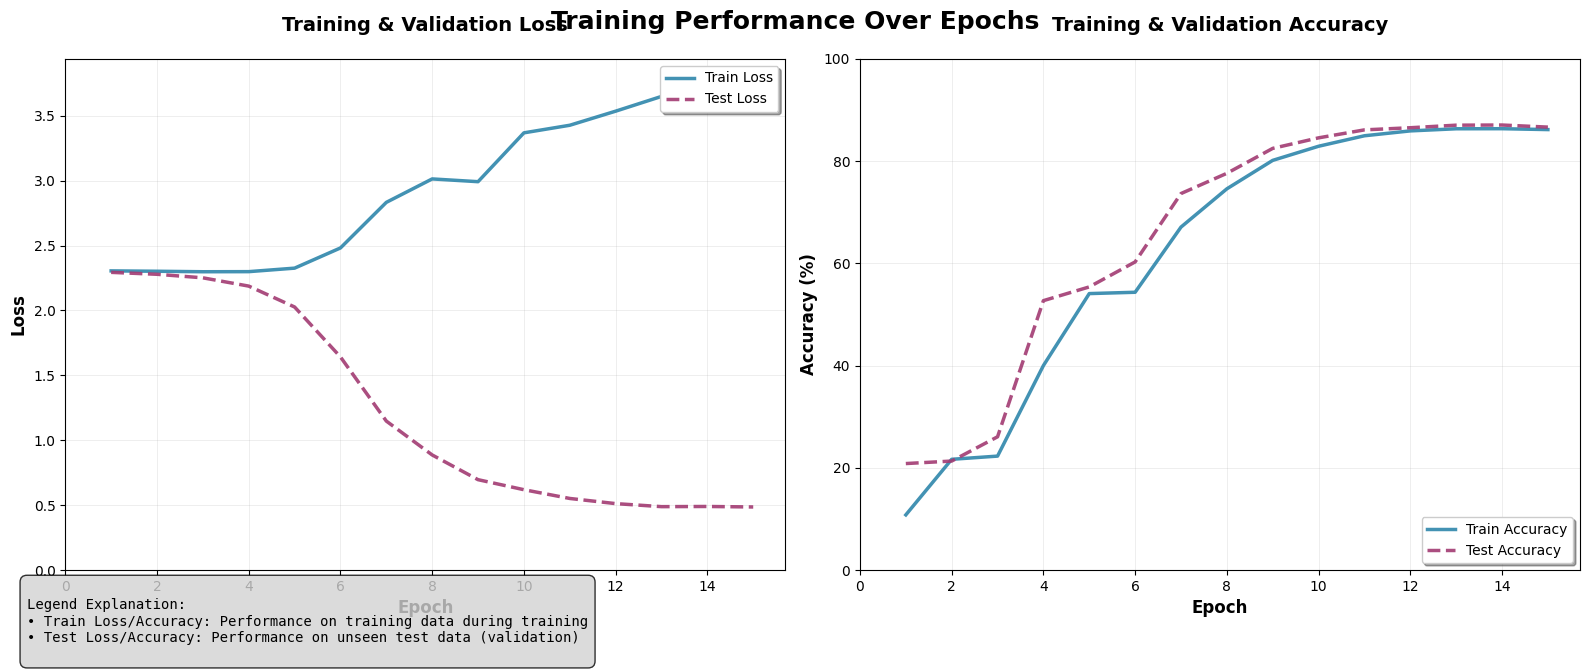

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Create epoch range
epochs = len(train_losses)
epoch_range = list(range(1, epochs + 1))

# Set up the figure
plt.rcParams.update({'font.size': 10})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define color palette
train_color = '#2E86AB'     # Blue
test_color = '#A23B72'      # Red/Purple

# --- Loss Plot ---
ax1.plot(epoch_range, train_losses, color=train_color, linewidth=2.5, 
         label='Train Loss', alpha=0.9)
ax1.plot(epoch_range, test_losses, color=test_color, linewidth=2.5, 
         linestyle='--', label='Test Loss', alpha=0.9)

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
ax2.plot(epoch_range, train_accuracies, color=train_color, linewidth=2.5, 
         label='Train Accuracy', alpha=0.9)
ax2.plot(epoch_range, test_accuracies, color=test_color, linewidth=2.5, 
         linestyle='--', label='Test Accuracy', alpha=0.9)

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Overall title
fig.suptitle('Training Performance Over Epochs', 
             fontsize=18, fontweight='bold', y=0.95)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.15)

# Glossary box (adjusted for simpler context)
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
"""

props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure
# plt.savefig('training_results.png', dpi=300, bbox_inches='tight', facecolor='white')